In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [4]:
df = pd.read_csv("Mall_Customers.csv")
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:

df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

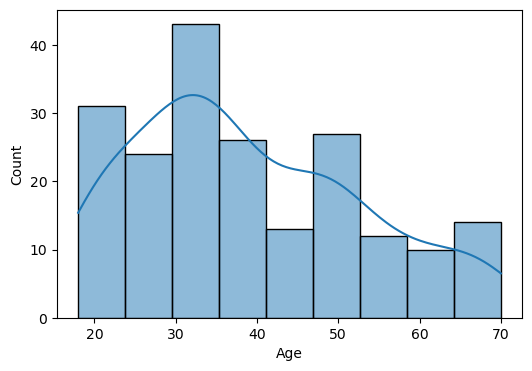

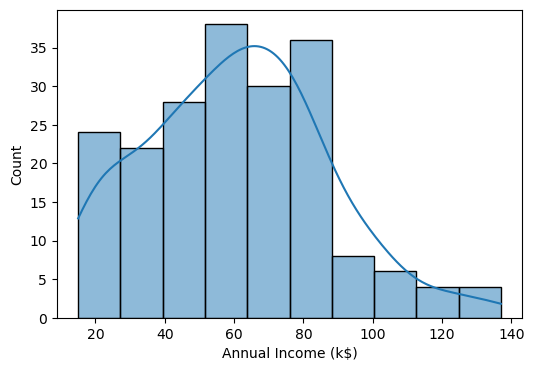

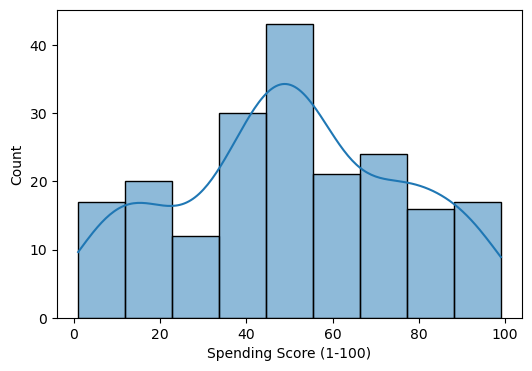

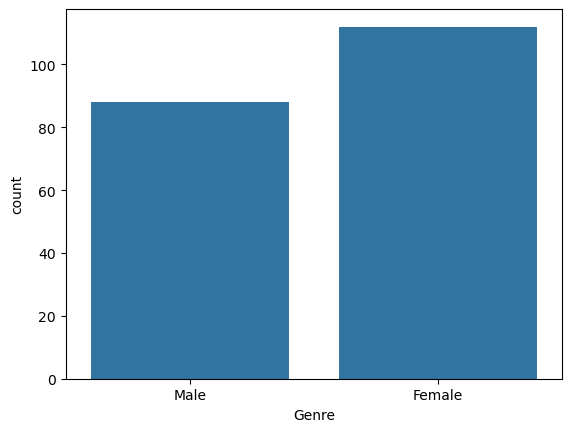

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], kde=True)
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.show()
sns.countplot(x='Genre', data=df)
plt.show()

In [8]:

df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})

In [9]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

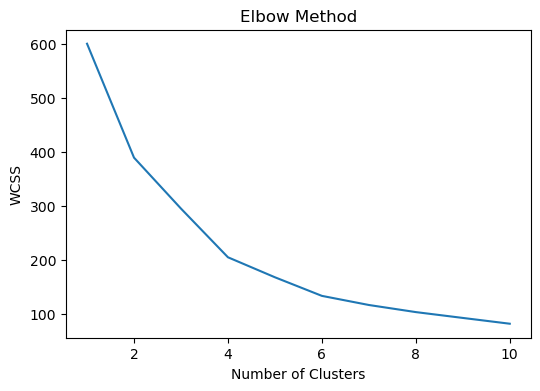

In [11]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [12]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [13]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.41664341513732767


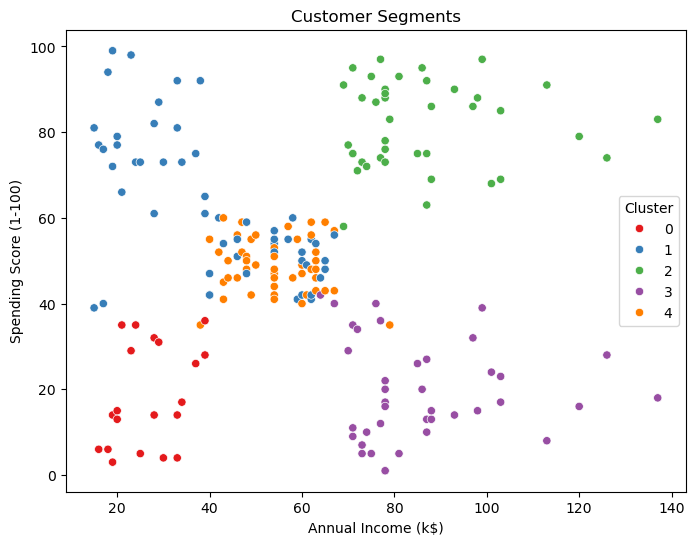

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df
)
plt.title("Customer Segments")
plt.show()

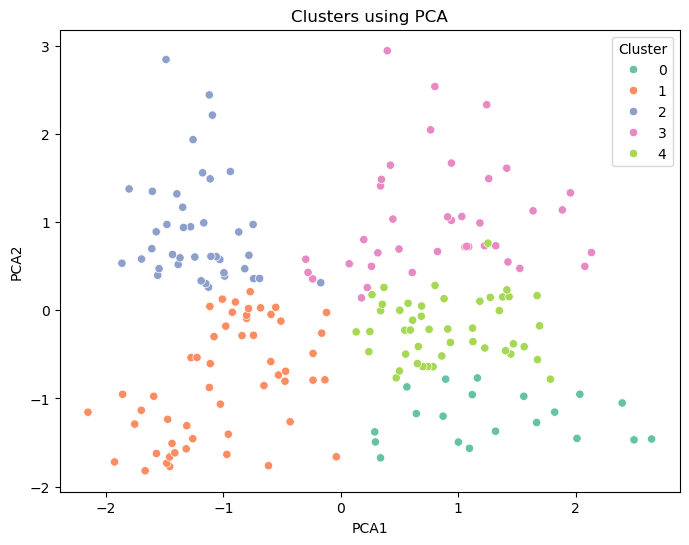

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=df,
    palette='Set2'
)
plt.title("Clusters using PCA")
plt.show()

In [16]:
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

         CustomerID     Genre        Age  Annual Income (k$)  \
Cluster                                                        
0         24.100000  0.600000  46.250000           26.750000   
1         55.648148  0.592593  25.185185           41.092593   
2        161.025000  0.550000  32.875000           86.100000   
3        159.743590  0.487179  39.871795           86.102564   
4         83.872340  0.574468  55.638298           54.382979   

         Spending Score (1-100)      PCA1      PCA2  
Cluster                                              
0                     18.350000  1.310308 -1.226286  
1                     62.240741 -0.987155 -0.789408  
2                     81.525000 -1.208516  0.914846  
3                     19.358974  0.850509  1.021244  
4                     48.851064  0.899383 -0.197204  


 Cluster 0: Older, low-income, low-spending customers
- Focus on budget-friendly promotions and loyalty programs.

Cluster 1: Young, mid-income, high-spending customers
- Target with social media campaigns, bundles, and seasonal deals.

Cluster 2: Mid-age, high-income, high-spending customers
- VIP programs, exclusive launches, and personalized recommendations.

Cluster 3: High-income, low-spending customers
- Loyalty rewards, targeted promotions, and upselling premium bundles.

Cluster 4: Older, moderate-income, moderate-spending customers
- Seasonal campaigns, cross-selling, and moderate social media marketing.